<a href="https://colab.research.google.com/github/ruudtje21/ai-sql-assistant/blob/main/korosi_detection_yolov12_rsnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Analisis Stabilitas Indikator Kerusakan Korosi
## Perbandingan YOLOv12 vs Faster R-CNN pada Kondisi Degradasi Citra

**Nama**  : Rudi Sumantri  
**NIM**   : 241012000065  
**Prodi** : Magister Teknik Informatika - Universitas Pamulang  

---

### Desain Penelitian
| Model | Framework | Data Training | Keterangan |
|-------|-----------|---------------|------------|
| yolo_A | YOLOv12n | Normal saja (214 gambar) | Baseline |
| yolo_B | YOLOv12n | Normal + Terdegradasi (214×6=1284 gambar) | Enhanced |
| rcnn_A | Faster R-CNN | Normal saja (214 gambar) | Baseline |
| rcnn_B | Faster R-CNN | Normal + Terdegradasi (214×6=1284 gambar) | Enhanced |

### Test Set (sama untuk semua model)
| Kondisi | Keterangan |
|---------|------------|
| original | Gambar asli tanpa perubahan |
| low_light | Brightness -20%, Contrast -15% |
| noisy | Gaussian noise sigma=15 |
| blurry | Gaussian blur 3×3 |
| compressed | JPEG quality=30 |
| combined | Semua digabung |

### Pertanyaan Penelitian
```
1. Apakah model yang dilatih data beragam (B) lebih robust
   dibanding model yang dilatih data normal (A)?
2. Arsitektur mana yang lebih tahan: YOLOv12 atau Faster R-CNN?
3. Apakah ranking keparahan korosi tetap konsisten
   meskipun kualitas citra menurun?
```

---

### Alur Notebook
```
SEL 1  → Install Library
SEL 2  → Import Library
SEL 3  → Definisi Path
SEL 4  → Setup Kaggle
SEL 5  → Download Dataset
SEL 6  → Split Dataset (80/20)
SEL 7  → Fix Class Index
SEL 8  → Validasi Kualitas Citra
SEL 9  → Degradasi Test Set & Augmentasi Training
SEL 9b → Histogram Perbandingan Luminance
SEL 10 → Buat data.yaml (2 file: normal & beragam)
SEL 11 → Training YOLOv12 Model A & B
SEL 12 → Evaluasi YOLO A & B
SEL 13 → Stabilitas YOLO
SEL 14 → Ranking Stability YOLO
SEL 15 → Rekap YOLO
SEL 16 → Konversi YOLO ke COCO (2 dataset)
SEL 17 → Register Dataset Detectron2
SEL 18 → Training RCNN Model A & B
SEL 19 → Cek Metrics RCNN
SEL 20 → Fungsi Visualisasi
SEL 21 → Evaluasi RCNN A & B
SEL 22 → Stabilitas RCNN
SEL 23 → Ranking Stability RCNN
SEL 24 → Rekap RCNN
SEL 25 → Perbandingan Semua Model
SEL 26 → Rekap Final
SEL 27 → Download Semua File
```

---
## SEL 1 — Install Library
Menginstal semua library yang dibutuhkan:
- `yolov12` : framework YOLOv12 (attention-centric, lebih akurat dari YOLOv8)
- `flash-attn` : FlashAttention untuk performa optimal YOLOv12 di GPU A100
- `detectron2` : framework Faster R-CNN dari Facebook Research

> ⚠️ YOLOv12 diinstall dari GitHub, **bukan** dari pip ultralytics biasa.

In [1]:
# Install YOLOv12 dari GitHub
!git clone https://github.com/sunsmarterjie/yolov12.git
%cd yolov12
!pip install -r requirements.txt -q
!pip install -e . -q
%cd ..

# Install FlashAttention (wajib untuk performa optimal YOLOv12 di A100)
!pip install flash-attn --no-build-isolation -q

# Install Detectron2 untuk Faster R-CNN
!pip install 'git+https://github.com/facebookresearch/detectron2.git' --quiet

print('Semua library berhasil diinstall!')
print('YOLOv12  : attention-centric')
print('Detectron2: framework Faster R-CNN')

Cloning into 'yolov12'...
remote: Enumerating objects: 1169, done.
remote: Total 1169 (delta 0), reused 0 (delta 0), pack-reused 1169 (from 1)
Receiving objects: 100% (1169/1169), 1.95 MiB | 12.77 MiB/s, done.
Resolving deltas: 100% (531/531), done.
/content/yolov12
ERROR: flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl is not a supported wheel on this platform.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 76.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Operation cancelled by user
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 

In [3]:
pip install ultralytics

In [4]:
import sys
sys.path.append('/content/yolov12')
import ultralytics
print("Siap mendeteksi korosi!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
Siap mendeteksi korosi!


In [5]:
import torch
import ultralytics
from detectron2.utils.logger import setup_logger
setup_logger()

# Cek apakah GPU terbaca
print(f"Setup Complete. Using Torch {torch.__version__} ({torch.cuda.get_device_name(0)})")

# Tes load model YOLOv12 (sesuaikan path jika berbeda)
try:
    from ultralytics import YOLO
    print("YOLOv12 ready!")
except:
    print("YOLOv12 need re-check.")

Setup Complete. Using Torch 2.10.0+cu128 (NVIDIA A100-SXM4-40GB)
YOLOv12 ready!


---
## SEL 2 — Import Library
Mengimpor semua library yang akan digunakan sepanjang notebook.

In [6]:
# Sistem & file management
import os
import shutil
import random
import json

# Komputasi & data
import numpy as np
import pandas as pd
from scipy import stats

# Computer vision
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# YOLOv12
from ultralytics import YOLO

# Detectron2 / Faster R-CNN
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.data.datasets import register_coco_instances

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


---
## SEL 3 — Definisi Path
Mendefinisikan semua path folder dataset di satu tempat agar mudah dikelola.

In [7]:
base        = '/content/datasets/corrosion detect'
images_path = f'{base}/images'
labels_path = f'{base}/labels'
img_train   = f'{base}/images/train'
img_val     = f'{base}/images/val'
lbl_train   = f'{base}/labels/train'
lbl_val     = f'{base}/labels/val'

print('✅ Path berhasil didefinisikan!')
print(f'   Base      : {base}')
print(f'   Train     : {img_train}')
print(f'   Val       : {img_val}')

✅ Path berhasil didefinisikan!
   Base      : /content/datasets/corrosion detect
   Train     : /content/datasets/corrosion detect/images/train
   Val       : /content/datasets/corrosion detect/images/val


---
## SEL 4 — Setup Kaggle
Mengkonfigurasi Kaggle API untuk mengunduh dataset.
Pastikan file `kaggle.json` sudah diupload ke Colab.

In [9]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('✅ Kaggle API berhasil dikonfigurasi!')

✅ Kaggle API berhasil dikonfigurasi!


---
## SEL 5 — Download Dataset
Mengunduh dataset korosi dari Kaggle.
Dataset berisi **268 gambar** korosi dengan anotasi bounding box format YOLO.
Dataset digunakan **apa adanya tanpa modifikasi gambar apapun**.

In [10]:
# Download dataset
!kaggle datasets download -d wednesday233/corrosion-detect-dataset
!unzip -q corrosion-detect-dataset.zip -d datasets/

# Cek nama folder hasil ekstrak
print('Isi folder datasets:')
print(os.listdir('/content/datasets'))

print('\n✅ Dataset berhasil didownload!')

Dataset URL: https://www.kaggle.com/datasets/wednesday233/corrosion-detect-dataset
License(s): MIT
100% 8.12M/8.12M [00:00<00:00, 63.5MB/s]

Isi folder datasets:
['corrosion detect']

✅ Dataset berhasil didownload!


---
## SEL 6 — Split Dataset (80/20)
Membagi dataset menjadi:
- **Training set : 80%** → 214 gambar (untuk melatih model)
- **Validation set: 20%** → 54 gambar (untuk menguji model)

`random.seed(42)` digunakan agar pembagian selalu sama setiap dijalankan.

In [11]:
# Buat folder train dan val
for split in ['train', 'val']:
    os.makedirs(os.path.join(images_path, split), exist_ok=True)
    os.makedirs(os.path.join(labels_path, split), exist_ok=True)

# Ambil semua gambar dari folder images
all_images = [f for f in os.listdir(images_path)
              if f.endswith(('.jpg', '.jpeg', '.png'))]

# Acak dan bagi 80/20
random.seed(42)
random.shuffle(all_images)
split_idx  = int(len(all_images) * 0.8)
train_imgs = all_images[:split_idx]
val_imgs   = all_images[split_idx:]

# Pindahkan file gambar dan label ke folder masing-masing
def move_files(file_list, split):
    for img_file in file_list:
        name    = os.path.splitext(img_file)[0]
        src_img = os.path.join(images_path, img_file)
        src_lbl = os.path.join(labels_path, name + '.txt')
        dst_img = os.path.join(images_path, split, img_file)
        dst_lbl = os.path.join(labels_path, split, name + '.txt')
        if os.path.exists(src_img):
            shutil.move(src_img, dst_img)
        if os.path.exists(src_lbl):
            shutil.move(src_lbl, dst_lbl)

move_files(train_imgs, 'train')
move_files(val_imgs,   'val')

print(f'✅ Split selesai!')
print(f'   Train : {len(os.listdir(img_train))} gambar')
print(f'   Val   : {len(os.listdir(img_val))} gambar')

✅ Split selesai!
   Train : 214 gambar
   Val   : 54 gambar


---
## SEL 7 — Fix Class Index
Memperbaiki kesalahan class index pada file label.
Beberapa label menggunakan index `1`, padahal dataset ini hanya memiliki
**1 kelas** (korosi) dengan index `0`.

> ⚠️ Ini bukan augmentasi atau editing gambar.
> Ini hanya perbaikan error pada file anotasi (.txt).

In [12]:
fixed = 0
for split in ['train', 'val']:
    folder = os.path.join(labels_path, split)
    for txt_file in os.listdir(folder):
        filepath = os.path.join(folder, txt_file)
        with open(filepath, 'r') as f:
            lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if parts:
                parts[0] = '0'  # Perbaiki class index ke 0
                new_lines.append(' '.join(parts) + '\n')
        with open(filepath, 'w') as f:
            f.writelines(new_lines)
        fixed += 1

print(f'✅ {fixed} file label berhasil diperbaiki!')

✅ 268 file label berhasil diperbaiki!


---
## SEL 8 — Validasi Kualitas Citra
Sebelum melakukan degradasi, perlu dipastikan bahwa test set **layak untuk didegradasi**.
Validasi dilakukan dengan:
1. **Cek Y ≤ 10** → gambar yang sudah terlalu gelap tidak akan didegradasi
2. **SNRrough** = rerata Y / sigma Y → mengukur variasi intensitas
3. **SNR** = Var(Signal) / Var(Noise) → mengukur kualitas sinyal gambar
4. **Histogram Luminance** → melihat distribusi intensitas gambar

Formula luminance: `Y = 0.299R + 0.587G + 0.114B`

1. CEK GAMBAR TERLALU GELAP (Y <= 10)
✅ Tidak ada gambar yang terlalu gelap (Y <= 10)

2. HITUNG SNRrough = rerata Y / sigma Y
SNRrough rata-rata : 1.363
SNRrough minimum   : 0.739
SNRrough maksimum  : 2.388
✅ Disimpan ke snr_rough.csv

3. HITUNG SNR = Var(Signal) / Var(Noise)
SNR rata-rata  : 416.834
SNR minimum    : 50.663
SNR maksimum   : 1641.464
✅ Disimpan ke snr_full.csv

4. HISTOGRAM LUMINANCE TEST SET (ORIGINAL)


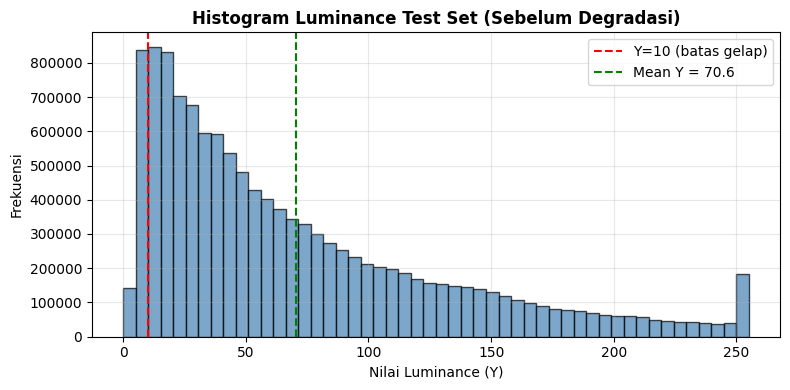

✅ Disimpan ke histogram_sebelum_degradasi.png


In [13]:
# ── 1. CEK GAMBAR TERLALU GELAP (Y <= 10) ────────────────────────
print('='*55)
print('1. CEK GAMBAR TERLALU GELAP (Y <= 10)')
print('='*55)
too_dark = []
for fname in os.listdir(img_val):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_bgr = cv2.imread(os.path.join(img_val, fname))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    Y       = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    if float(Y.mean()) <= 10:
        too_dark.append({'file': fname, 'mean_Y': round(float(Y.mean()), 2)})

if too_dark:
    print(f'⚠️ {len(too_dark)} gambar terlalu gelap (Y <= 10):')
    print(pd.DataFrame(too_dark))
else:
    print('✅ Tidak ada gambar yang terlalu gelap (Y <= 10)')

# ── 2. HITUNG SNRrough ────────────────────────────────────────────
print('\n' + '='*55)
print('2. HITUNG SNRrough = rerata Y / sigma Y')
print('='*55)
snr_log = []
for fname in os.listdir(img_val):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_bgr = cv2.imread(os.path.join(img_val, fname))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    Y       = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    mean_Y  = float(Y.mean())
    std_Y   = float(Y.std())
    snr_rough = mean_Y / std_Y if std_Y != 0 else 0
    snr_log.append({'file': fname, 'mean_Y': round(mean_Y, 2),
                    'std_Y': round(std_Y, 2), 'SNRrough': round(snr_rough, 3)})

df_snr = pd.DataFrame(snr_log)
df_snr.to_csv('snr_rough.csv', index=False)
print(f'SNRrough rata-rata : {df_snr["SNRrough"].mean():.3f}')
print(f'SNRrough minimum   : {df_snr["SNRrough"].min():.3f}')
print(f'SNRrough maksimum  : {df_snr["SNRrough"].max():.3f}')
print('✅ Disimpan ke snr_rough.csv')

# ── 3. HITUNG SNR = Var(Signal) / Var(Noise) ─────────────────────
print('\n' + '='*55)
print('3. HITUNG SNR = Var(Signal) / Var(Noise)')
print('='*55)
snr_full_log = []
for fname in os.listdir(img_val):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_bgr = cv2.imread(os.path.join(img_val, fname))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    Y       = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    signal  = cv2.GaussianBlur(Y.astype(np.uint8), (5,5), 0).astype(float)
    noise   = Y - signal
    var_s   = float(np.var(signal))
    var_n   = float(np.var(noise))
    snr     = var_s / var_n if var_n != 0 else 0
    snr_full_log.append({'file': fname, 'var_signal': round(var_s, 3),
                         'var_noise': round(var_n, 3), 'SNR': round(snr, 3)})

df_snr_full = pd.DataFrame(snr_full_log)
df_snr_full.to_csv('snr_full.csv', index=False)
print(f'SNR rata-rata  : {df_snr_full["SNR"].mean():.3f}')
print(f'SNR minimum    : {df_snr_full["SNR"].min():.3f}')
print(f'SNR maksimum   : {df_snr_full["SNR"].max():.3f}')
print('✅ Disimpan ke snr_full.csv')

# ── 4. HISTOGRAM LUMINANCE ────────────────────────────────────────
print('\n' + '='*55)
print('4. HISTOGRAM LUMINANCE TEST SET (ORIGINAL)')
print('='*55)
all_Y = []
for fname in os.listdir(img_val):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_bgr = cv2.imread(os.path.join(img_val, fname))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    Y       = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    all_Y.extend(Y.flatten().tolist())

plt.figure(figsize=(8, 4))
plt.hist(all_Y, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(x=10, color='red', linestyle='--', label='Y=10 (batas gelap)')
plt.axvline(x=np.mean(all_Y), color='green', linestyle='--',
            label=f'Mean Y = {np.mean(all_Y):.1f}')
plt.title('Histogram Luminance Test Set (Sebelum Degradasi)', fontweight='bold')
plt.xlabel('Nilai Luminance (Y)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('histogram_sebelum_degradasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan ke histogram_sebelum_degradasi.png')

---
## SEL 9 — Degradasi Test Set & Persiapan Training Beragam
Dua fungsi utama sel ini:

**1. Degradasi Test Set** → mensimulasikan kondisi lapangan

| Kondisi | Degradasi | Keterangan |
|---------|-----------|------------|
| `low_light` | Brightness -20%, Contrast -15% | Cahaya redup |
| `noisy` | Gaussian noise sigma=15 | Sensor noise |
| `blurry` | Gaussian blur 3×3 | Kamera tidak fokus |
| `compressed` | JPEG quality=30 | Kompresi tinggi |
| `combined` | Semua digabung | Kondisi terburuk |

**2. Augmentasi Training** → untuk Model B
- Training B = data normal (214) + semua degradasi (214×5=1070)
- Total training B = **1284 gambar**

> ⚠️ Test set dan training B menggunakan **degradasi yang sama**
> agar perbandingan adil.

In [14]:
import tempfile

# ── FUNGSI DEGRADASI ──────────────────────────────────────────
def apply_low_light(img_rgb):
    """Brightness -20%, Contrast -15%"""
    deg    = img_rgb.copy() * 0.80
    mean_d = deg.mean(axis=(0,1), keepdims=True)
    deg    = (deg - mean_d) * 0.85 + mean_d
    return np.clip(deg, 0, 255)

def apply_noise(img_rgb):
    """Gaussian noise sigma=15"""
    noise = np.random.normal(0, 15, img_rgb.shape)
    return np.clip(img_rgb + noise, 0, 255)

def apply_blur(img_rgb):
    """Gaussian blur kernel 3x3"""
    blurred = cv2.GaussianBlur(img_rgb.astype(np.uint8), (3,3), 0)
    return blurred.astype(float)

def apply_compression(img_rgb, quality=30):
    """JPEG compression quality=30"""
    img_bgr = cv2.cvtColor(img_rgb.astype(np.uint8), cv2.COLOR_RGB2BGR)
    _, enc  = cv2.imencode('.jpg', img_bgr, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    dec     = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB).astype(float)

def apply_combined(img_rgb):
    """Gabungan: low light + noise + blur + kompresi"""
    deg = apply_low_light(img_rgb)
    deg = apply_noise(deg)
    deg = apply_blur(deg)
    deg = apply_compression(deg, quality=40)
    return np.clip(deg, 0, 255)

# Daftar semua jenis degradasi
degradations = {
    'low_light'  : apply_low_light,
    'noisy'      : apply_noise,
    'blurry'     : apply_blur,
    'compressed' : apply_compression,
    'combined'   : apply_combined,
}

# ── BAGIAN 1: DEGRADASI TEST SET ──────────────────────────────
print('='*55)
print('BAGIAN 1 — DEGRADASI TEST SET')
print('='*55)
for deg_name in degradations:
    os.makedirs(f'{images_path}/{deg_name}', exist_ok=True)

log = []
for fname in os.listdir(img_val):
    if not fname.lower().endswith(('.jpg','.jpeg','.png')):
        continue
    fpath   = os.path.join(img_val, fname)
    img_bgr = cv2.imread(fpath)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
    Y_ori     = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
    mean_awal = float(Y_ori.mean())
    std_awal  = float(Y_ori.std())
    for deg_name, deg_func in degradations.items():
        deg      = deg_func(img_rgb)
        Y_deg    = 0.299*deg[:,:,0] + 0.587*deg[:,:,1] + 0.114*deg[:,:,2]
        mean_deg = float(Y_deg.mean())
        std_deg  = float(Y_deg.std())
        out_path = f'{images_path}/{deg_name}/{fname}'
        if mean_deg < 0.7*mean_awal or std_deg < 0.6*std_awal:
            shutil.copy(fpath, out_path)
            status = 'SKIP'
        else:
            cv2.imwrite(out_path,
                cv2.cvtColor(deg.astype(np.uint8), cv2.COLOR_RGB2BGR))
            status = 'OK'
        log.append({'file': fname, 'level': deg_name, 'status': status})

df_log = pd.DataFrame(log)
print(df_log.groupby(['level','status']).size())
print(f'✅ Test set terdegradasi selesai!')

# ── BAGIAN 2: AUGMENTASI TRAINING UNTUK MODEL B ───────────────
print('\n' + '='*55)
print('BAGIAN 2 — AUGMENTASI TRAINING (untuk Model B)')
print('='*55)

# Buat folder training augmented
img_train_aug = f'{images_path}/train_augmented'
lbl_train_aug = f'{labels_path}/train_augmented'
os.makedirs(img_train_aug, exist_ok=True)
os.makedirs(lbl_train_aug, exist_ok=True)

# Copy semua gambar training normal dulu
count = 0
for fname in os.listdir(img_train):
    if not fname.lower().endswith(('.jpg','.jpeg','.png')):
        continue
    name    = os.path.splitext(fname)[0]
    src_img = os.path.join(img_train, fname)
    src_lbl = os.path.join(lbl_train, name + '.txt')
    shutil.copy(src_img, os.path.join(img_train_aug, fname))
    if os.path.exists(src_lbl):
        shutil.copy(src_lbl, os.path.join(lbl_train_aug, name + '.txt'))
    count += 1

print(f'Data normal disalin: {count} gambar')

# Tambahkan versi terdegradasi ke training B
aug_count = 0
for fname in os.listdir(img_train):
    if not fname.lower().endswith(('.jpg','.jpeg','.png')):
        continue
    name    = os.path.splitext(fname)[0]
    fpath   = os.path.join(img_train, fname)
    src_lbl = os.path.join(lbl_train, name + '.txt')
    img_bgr = cv2.imread(fpath)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)

    for deg_name, deg_func in degradations.items():
        # Nama file baru dengan suffix degradasi
        new_name    = f'{name}_{deg_name}'
        new_fname   = f'{new_name}.jpg'
        out_img     = os.path.join(img_train_aug, new_fname)
        out_lbl     = os.path.join(lbl_train_aug, new_name + '.txt')
        # Terapkan degradasi
        deg = deg_func(img_rgb)
        cv2.imwrite(out_img,
            cv2.cvtColor(deg.astype(np.uint8), cv2.COLOR_RGB2BGR))
        # Copy label yang sama
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, out_lbl)
        aug_count += 1

total_aug = len([f for f in os.listdir(img_train_aug)
                 if f.endswith(('.jpg','.jpeg','.png'))])
print(f'Data terdegradasi ditambahkan: {aug_count} gambar')
print(f'Total training Model B: {total_aug} gambar')
print(f'✅ Augmentasi training selesai!')


BAGIAN 1 — DEGRADASI TEST SET
level       status
blurry      OK        54
combined    OK        54
compressed  OK        54
low_light   OK        54
noisy       OK        54
dtype: int64
✅ Test set terdegradasi selesai!

BAGIAN 2 — AUGMENTASI TRAINING (untuk Model B)
Data normal disalin: 214 gambar
Data terdegradasi ditambahkan: 1070 gambar
Total training Model B: 1284 gambar
✅ Augmentasi training selesai!


---
## SEL 9b — Histogram Perbandingan Setelah Degradasi
Memvisualisasikan distribusi luminance pada ketiga kondisi test set
untuk memastikan degradasi bermakna dan tidak berlebihan.

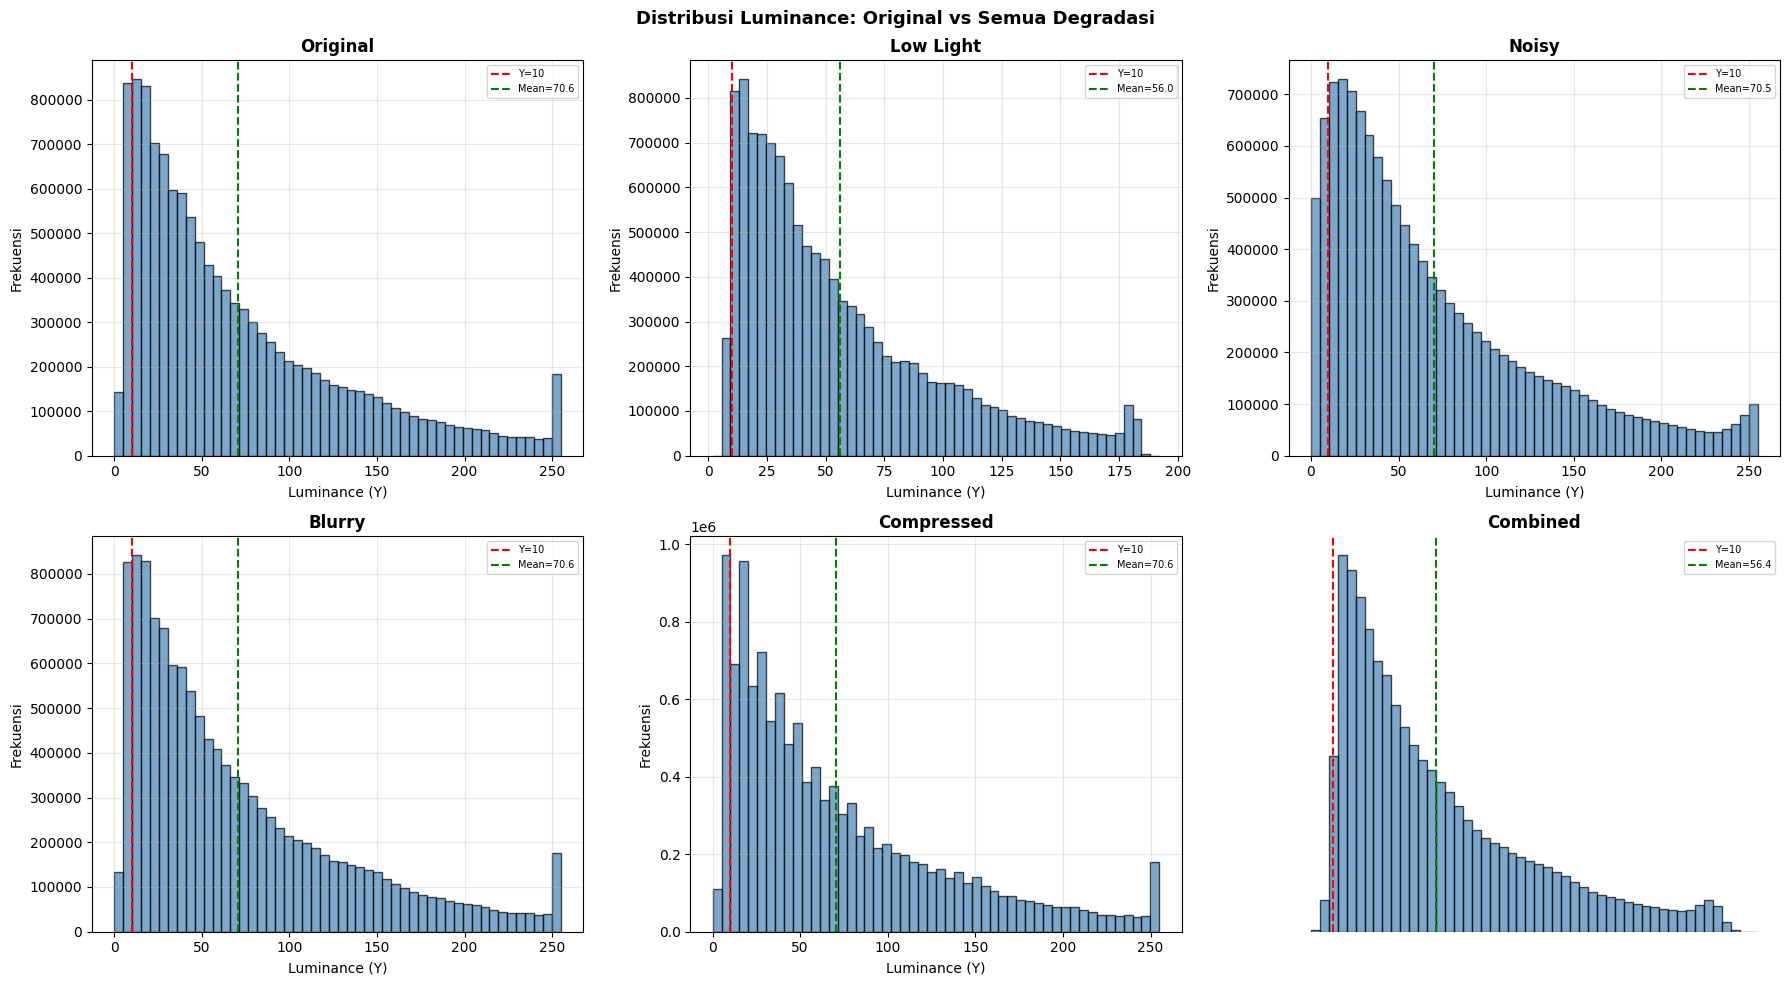

✅ Disimpan ke histogram_luminance.png


In [15]:
test_conditions = {
    'Original'   : img_val,
    'Low Light'  : f'{images_path}/low_light',
    'Noisy'      : f'{images_path}/noisy',
    'Blurry'     : f'{images_path}/blurry',
    'Compressed' : f'{images_path}/compressed',
    'Combined'   : f'{images_path}/combined',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, (ax, (condition, path)) in enumerate(zip(axes, test_conditions.items())):
    all_Y = []
    for fname in os.listdir(path):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_bgr = cv2.imread(os.path.join(path, fname))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(float)
        Y       = 0.299*img_rgb[:,:,0] + 0.587*img_rgb[:,:,1] + 0.114*img_rgb[:,:,2]
        all_Y.extend(Y.flatten().tolist())
    ax.hist(all_Y, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(x=10, color='red', linestyle='--', label='Y=10')
    ax.axvline(x=np.mean(all_Y), color='green', linestyle='--',
               label=f'Mean={np.mean(all_Y):.1f}')
    ax.set_title(f'{condition}', fontweight='bold')
    ax.set_xlabel('Luminance (Y)')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Sembunyikan subplot ke-6 yang kosong
axes[5].axis('off')

plt.suptitle('Distribusi Luminance: Original vs Semua Degradasi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histogram_luminance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan ke histogram_luminance.png')


---
## SEL 10 — Buat data.yaml
Membuat **2 file yaml** untuk 2 model yang berbeda:
- `data.yaml` → Model A (training normal saja)
- `data_augmented.yaml` → Model B (training normal + terdegradasi)

In [16]:
import yaml

# data.yaml → Model A (dataset normal saja)
data_yaml = {
    'path' : base,
    'train': 'images/train',
    'val'  : 'images/val',
    'nc'   : 1,
    'names': ['corrosion']
}
with open(f'{base}/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

# data_augmented.yaml → Model B (normal + terdegradasi)
data_yaml_aug = {
    'path' : base,
    'train': 'images/train_augmented',
    'val'  : 'images/val',
    'nc'   : 1,
    'names': ['corrosion']
}
with open(f'{base}/data_augmented.yaml', 'w') as f:
    yaml.dump(data_yaml_aug, f)

print('✅ File yaml berhasil dibuat!')
print(f'   data.yaml          → training normal ({len(os.listdir(img_train))} gambar)')
print(f'   data_augmented.yaml → training normal + terdegradasi')


✅ File yaml berhasil dibuat!
   data.yaml          → training normal (214 gambar)
   data_augmented.yaml → training normal + terdegradasi


---
## SEL 11 — Training YOLOv12
Melatih model YOLOv12 menggunakan **dataset asli apa adanya**.

| Parameter | Nilai | Keterangan |
|-----------|-------|------------|
| Model | yolov12n | Versi nano, attention-centric |
| Epochs | 50 | Jumlah iterasi training |
| Batch | 16 | Jumlah gambar per batch |
| Imgsz | 640 | Ukuran gambar input |

**Keunggulan YOLOv12 vs YOLOv8:**
- Menggunakan Area Attention mechanism (bukan CNN biasa)
- mAP lebih tinggi dengan kecepatan kompetitif
- FlashAttention untuk efisiensi memori di GPU A100

Model terbaik disimpan otomatis sebagai `best.pt`.

In [17]:
# ── MODEL A: Training dengan data NORMAL ─────────────────────
print('='*50)
print('Training yolo_A — Data Normal...')
print('='*50)
model_yolo_A = YOLO('yolov12n.pt')
model_yolo_A.train(
    data     = f'{base}/data.yaml',
    epochs   = 50,
    imgsz    = 640,
    batch    = 16,
    name     = 'yolo_A',
    project  = '/content/runs/yolo',
    exist_ok = True,
)
print('✅ yolo_A selesai!')
print('   Model : /content/runs/yolo/yolo_A/weights/best.pt')

# ── MODEL B: Training dengan data NORMAL + TERDEGRADASI ───────
print('\n' + '='*50)
print('Training yolo_B — Data Normal + Terdegradasi...')
print('='*50)
model_yolo_B = YOLO('yolov12n.pt')
model_yolo_B.train(
    data     = f'{base}/data_augmented.yaml',
    epochs   = 50,
    imgsz    = 640,
    batch    = 16,
    name     = 'yolo_B',
    project  = '/content/runs/yolo',
    exist_ok = True,
)
print('✅ yolo_B selesai!')
print('   Model : /content/runs/yolo/yolo_B/weights/best.pt')
print('\n✅ Semua model YOLOv12 selesai ditraining!')


Training yolo_A — Data Normal...


100%|██████████| 5.26M/5.26M [00:00<00:00, 73.4MB/s]


New https://pypi.org/project/ultralytics/8.4.47 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: task=detect, mode=train, model=yolov12n.pt, data=/content/datasets/corrosion detect/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/runs/yolo, name=yolo_A, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_ma

100%|██████████| 755k/755k [00:00<00:00, 17.1MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      2368  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2, 1, 2]          
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1      9344  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2, 1, 4]          
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    174720  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics

...

      50/50      3.78G     0.7836     0.4358     0.9258         72        640: 100%|██████████| 80/80 [00:12<00:00,  6.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  7.28it/s]

                   all         52        419      0.427      0.434      0.362      0.119



50 epochs completed in 0.196 hours.
Optimizer stripped from /content/runs/yolo/yolo_B/weights/last.pt, 5.4MB
Optimizer stripped from /content/runs/yolo/yolo_B/weights/best.pt, 5.4MB

Validating /content/runs/yolo/yolo_B/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv12n summary (fused): 376 layers, 2,508,539 parameters, 0 gradients, 5.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  5.54it/s]


                   all         52        419      0.398      0.449      0.385      0.129
Speed: 0.1ms preprocess, 0.7ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/yolo/yolo_B
✅ yolo_B selesai!
   Model : /content/runs/yolo/yolo_B/weights/best.pt

✅ Semua model YOLOv12 selesai ditraining!


---
## SEL 12 — Evaluasi YOLOv12 pada Test Set
Menguji model yolo_A (YOLOv12n) pada 6 kondisi test set:
- `original` → gambar asli
- `low_light` → cahaya redup
- `noisy` → ada noise
- `blurry` → gambar blur
- `compressed` → kompresi JPEG rendah
- `combined` → semua digabung

Indikator yang dihitung per gambar:
- **n_instance** : jumlah bounding box korosi terdeteksi
- **area_ratio** : total luas kotak ÷ luas gambar
- **box_density** : jumlah kotak per 1 juta piksel

In [18]:
test_sets = {
    'original'   : img_val,
    'low_light'  : f'{images_path}/low_light',
    'noisy'      : f'{images_path}/noisy',
    'blurry'     : f'{images_path}/blurry',
    'compressed' : f'{images_path}/compressed',
    'combined'   : f'{images_path}/combined',
}

results_log_yolo = []

# Evaluasi kedua model YOLO
yolo_models = {
    'yolo_A': YOLO('/content/runs/yolo/yolo_A/weights/best.pt'),
    'yolo_B': YOLO('/content/runs/yolo/yolo_B/weights/best.pt'),
}

for model_name, model in yolo_models.items():
    for test_name, test_path in test_sets.items():
        print(f'Evaluasi {model_name} pada {test_name}...')
        for fname in os.listdir(test_path):
            if not fname.lower().endswith(('.jpg','.jpeg','.png')):
                continue
            img_path     = os.path.join(test_path, fname)
            img_bgr      = cv2.imread(img_path)
            img_h, img_w = img_bgr.shape[:2]
            results      = model(img_path, verbose=False)
            boxes        = results[0].boxes
            n_instance   = len(boxes)
            if n_instance > 0:
                areas = []
                for box in boxes.xyxy.cpu().numpy():
                    x1, y1, x2, y2 = box
                    areas.append(((x2-x1)/img_w) * ((y2-y1)/img_h))
                area_ratio  = sum(areas)
                box_density = n_instance / (img_w * img_h) * 1e6
            else:
                area_ratio  = 0.0
                box_density = 0.0
            results_log_yolo.append({
                'model'      : model_name,
                'test_set'   : test_name,
                'file'       : fname,
                'n_instance' : n_instance,
                'area_ratio' : round(area_ratio, 4),
                'box_density': round(box_density, 4),
            })

df_yolo = pd.DataFrame(results_log_yolo)
df_yolo.to_csv('eval_results_yolo.csv', index=False)
print('\n✅ Evaluasi YOLO selesai!')
print(df_yolo.groupby(['model','test_set'])['n_instance'].mean().round(2))


Evaluasi yolo_A pada original...
Evaluasi yolo_A pada low_light...
Evaluasi yolo_A pada noisy...
Evaluasi yolo_A pada blurry...
Evaluasi yolo_A pada compressed...
Evaluasi yolo_A pada combined...
Evaluasi yolo_B pada original...
Evaluasi yolo_B pada low_light...
Evaluasi yolo_B pada noisy...
Evaluasi yolo_B pada blurry...
Evaluasi yolo_B pada compressed...
Evaluasi yolo_B pada combined...

✅ Evaluasi YOLO selesai!
model   test_set  
yolo_A  blurry        6.54
        combined      2.44
        compressed    7.17
        low_light     7.59
        noisy         1.94
        original      8.15
yolo_B  blurry        8.11
        combined      6.20
        compressed    8.24
        low_light     8.87
        noisy         7.96
        original      9.76
Name: n_instance, dtype: float64


---
## SEL 13 — Hitung Stabilitas YOLO
Mengukur seberapa stabil indikator kerusakan ketika kualitas citra menurun.

| Metrik | Formula | Interpretasi |
|--------|---------|---------------|
| CV (%) | std/mean × 100% | Makin kecil = makin stabil |
| Relative Change (%) | (mod-ori)/ori × 100% | Makin kecil = makin stabil |
| Spearman Trend | korelasi(level, nilai) | -1.0 = turun konsisten |

In [19]:
metrics_cols = ['n_instance', 'area_ratio', 'box_density']
test_order   = ['original', 'low_light', 'noisy', 'blurry', 'compressed', 'combined']
stability_log = []

df_yolo = pd.read_csv('eval_results_yolo.csv')

for metric in metrics_cols:
    means = {ts: df_yolo[df_yolo['test_set']==ts][metric].mean() for ts in test_order}
    vals  = [means[ts] for ts in test_order]
    cv    = (np.std(vals) / np.mean(vals) * 100) if np.mean(vals) != 0 else 0
    # Relative change dari original ke combined (kondisi terburuk)
    rel_change = ((means['combined'] - means['original']) / means['original'] * 100) \
                  if means['original'] != 0 else 0
    deg_levels = [0, 1, 2, 3, 4, 5]
    spearman_r, spearman_p = stats.spearmanr(deg_levels, vals)
    stability_log.append({
        'model'        : 'yolo_A',
        'metric'       : metric,
        'mean_ori'     : round(means['original'], 4),
        'mean_lowlight': round(means['low_light'], 4),
        'mean_noisy'   : round(means['noisy'], 4),
        'mean_blurry'  : round(means['blurry'], 4),
        'mean_compressed': round(means['compressed'], 4),
    'mean_combined': round(means['combined'], 4),
        'CV(%)'        : round(cv, 2),
        'rel_change(%)': round(rel_change, 2),
        'spearman_r'   : round(spearman_r, 3),
        'spearman_p'   : round(spearman_p, 3),
    })

df_stab_yolo = pd.DataFrame(stability_log)
df_stab_yolo.to_csv('stability_results_yolo.csv', index=False)

print('='*60)
print('HASIL STABILITAS YOLOv12')
print('='*60)
print(df_stab_yolo[['metric','CV(%)','rel_change(%)','spearman_r']].to_string(index=False))
print('\n✅ Disimpan ke stability_results_yolo.csv')

HASIL STABILITAS YOLOv12
     metric  CV(%)  rel_change(%)  spearman_r
 n_instance  24.51         -51.71      -0.771
 area_ratio  18.60         -21.64      -0.200
box_density  26.07         -54.63      -0.771

✅ Disimpan ke stability_results_yolo.csv


---
## SEL 14 — Ranking Stability YOLO
Mengukur apakah **urutan ranking** gambar berdasarkan tingkat korosi
tetap konsisten meskipun kualitas citra menurun.

Model dinyatakan **rank-stable** jika Spearman > 0.7

In [20]:
df_yolo     = pd.read_csv('eval_results_yolo.csv')
ranking_log = []
test_order  = ['original', 'low_light', 'noisy', 'blurry', 'compressed', 'combined']

for metric in metrics_cols:
    ranks = {}
    for ts in test_order:
        vals      = df_yolo[df_yolo['test_set']==ts].set_index('file')[metric]
        ranks[ts] = vals.rank(ascending=False)
    # Cari file yang sama di semua kondisi
    common = set(ranks['original'].index)
    for ts in test_order[1:]:
        common &= set(ranks[ts].index)
    common = list(common)
    # Hitung spearman untuk setiap kondisi vs original
    r_ll, _ = stats.spearmanr(ranks['original'][common], ranks['low_light'][common])
    r_no, _ = stats.spearmanr(ranks['original'][common], ranks['noisy'][common])
    r_bl, _ = stats.spearmanr(ranks['original'][common], ranks['blurry'][common])
    r_cp, _ = stats.spearmanr(ranks['original'][common], ranks['compressed'][common])
    r_co, _ = stats.spearmanr(ranks['original'][common], ranks['combined'][common])
    ranking_log.append({
        'model'               : 'yolo_A',
        'metric'              : metric,
        'spearman_low_light'  : round(r_ll, 3),
        'spearman_noisy'      : round(r_no, 3),
        'spearman_blurry'     : round(r_bl, 3),
        'spearman_compressed' : round(r_cp, 3),
        'spearman_combined'   : round(r_co, 3),
        'rank_stable'         : 'YA' if r_co > 0.7 else 'TIDAK'
    })

df_rank_yolo = pd.DataFrame(ranking_log)
df_rank_yolo.to_csv('ranking_stability_yolo.csv', index=False)

print('='*60)
print('RANKING STABILITY YOLOv12')
print('='*60)
print(df_rank_yolo.to_string(index=False))
print('\n✅ Disimpan ke ranking_stability_yolo.csv')

RANKING STABILITY YOLOv12
 model      metric  spearman_low_light  spearman_noisy  spearman_blurry  spearman_compressed  spearman_combined rank_stable
yolo_A  n_instance               0.970           0.715            0.949                0.929              0.748          YA
yolo_A  area_ratio               0.965           0.787            0.976                0.963              0.748          YA
yolo_A box_density               0.976           0.727            0.945                0.942              0.770          YA

✅ Disimpan ke ranking_stability_yolo.csv


---
## SEL 15 — Rekap Hasil YOLO
Menggabungkan semua hasil evaluasi dan stabilitas YOLOv8 dalam satu tabel.

In [22]:
df_s = pd.read_csv('stability_results_yolo.csv')
df_r = pd.read_csv('ranking_stability_yolo.csv')

rows = []
for metric in metrics_cols:
    s = df_s[df_s['metric']==metric].iloc[0]
    r = df_r[df_r['metric']==metric].iloc[0]
    rows.append({
        'Model'            : 'yolo_A',
        'Metrik'           : metric,
        'Mean_Ori'         : s['mean_ori'],
        'Mean_Mild'        : s['mean_lowlight'],
        'Mean_Moderate'    : s['mean_combined'],
        'CV_pct'           : s['CV(%)'],
        'RelChange_pct'    : s['rel_change(%)'],
        'Spearman_trend'   : s['spearman_r'],
        'Spearman_Ori_Mod' : r['spearman_combined'],
        'Rank_Stabil'      : r['rank_stable'],
    })

df_rekap_yolo = pd.DataFrame(rows)
df_rekap_yolo.to_csv('rekap_yolo.csv', index=False)
print('REKAP HASIL YOLOv12')
print('='*70)
print(df_rekap_yolo.to_string(index=False))
print('\n✅ Disimpan ke rekap_yolo.csv')

REKAP HASIL YOLOv12
 Model      Metrik  Mean_Ori  Mean_Mild  Mean_Moderate  CV_pct  RelChange_pct  Spearman_trend  Spearman_Ori_Mod Rank_Stabil
yolo_A  n_instance    8.9537     8.2315         4.3241   24.51         -51.71          -0.771             0.748          YA
yolo_A  area_ratio    0.2056     0.1929         0.1611   18.60         -21.64          -0.200             0.748          YA
yolo_A box_density   48.9407    45.3650        22.2036   26.07         -54.63          -0.771             0.770          YA

✅ Disimpan ke rekap_yolo.csv


---
## SEL 16 — Konversi YOLO ke Format COCO
Faster R-CNN (Detectron2) membutuhkan format anotasi **COCO (.json)**,
berbeda dengan YOLOv8 yang menggunakan format **.txt**.

Konversi dilakukan dari koordinat relatif (YOLO) ke koordinat piksel absolut (COCO).

In [23]:
def yolo_to_coco(images_dir, labels_dir, output_json):
    images, annotations, ann_id = [], [], 1
    for img_id, fname in enumerate(sorted(
        [f for f in os.listdir(images_dir)
         if f.endswith(('.jpg','.jpeg','.png'))]), 1):
        img   = cv2.imread(os.path.join(images_dir, fname))
        h, w  = img.shape[:2]
        images.append({'id': img_id, 'file_name': fname, 'height': h, 'width': w})
        label_file = os.path.join(labels_dir, os.path.splitext(fname)[0] + '.txt')
        if not os.path.exists(label_file):
            continue
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, cx, cy, bw, bh = map(float, parts[:5])
                x1, y1 = (cx - bw/2) * w, (cy - bh/2) * h
                bw_px, bh_px = bw * w, bh * h
                annotations.append({
                    'id': ann_id, 'image_id': img_id, 'category_id': 1,
                    'bbox': [x1, y1, bw_px, bh_px],
                    'area': bw_px * bh_px, 'iscrowd': 0
                })
                ann_id += 1
    coco = {'images': images, 'annotations': annotations,
            'categories': [{'id': 1, 'name': 'corrosion'}]}
    with open(output_json, 'w') as f:
        json.dump(coco, f)
    print(f'✅ {os.path.basename(output_json)} → {len(images)} gambar, {len(annotations)} anotasi')

# Model A → data normal
yolo_to_coco(img_train,     lbl_train,     f'{base}/train.json')
# Model B → data normal + terdegradasi
yolo_to_coco(img_train_aug, lbl_train_aug, f'{base}/train_augmented.json')
# Validasi
yolo_to_coco(img_val,       lbl_val,       f'{base}/val.json')
print('\n✅ Semua konversi selesai!')


✅ train.json → 214 gambar, 1671 anotasi
✅ train_augmented.json → 1284 gambar, 10026 anotasi
✅ val.json → 54 gambar, 461 anotasi

✅ Semua konversi selesai!


---
## SEL 17 — Register Dataset ke Detectron2
Mendaftarkan dataset ke katalog internal Detectron2
sebelum dapat digunakan untuk training.

In [24]:
# Model A → data normal
register_coco_instances('corrosion_train',     {}, f'{base}/train.json',           img_train)
# Model B → data normal + terdegradasi
register_coco_instances('corrosion_train_aug', {}, f'{base}/train_augmented.json', img_train_aug)
# Validasi
register_coco_instances('corrosion_val',       {}, f'{base}/val.json',             img_val)
print('✅ Dataset berhasil didaftarkan!')
print('   corrosion_train     → Model A (normal)')
print('   corrosion_train_aug → Model B (normal + terdegradasi)')


✅ Dataset berhasil didaftarkan!
   corrosion_train     → Model A (normal)
   corrosion_train_aug → Model B (normal + terdegradasi)


---
## SEL 18 — Training Faster R-CNN
Melatih model Faster R-CNN menggunakan **dataset asli apa adanya**.

| Parameter | Nilai | Keterangan |
|-----------|-------|------------|
| Backbone | ResNet-50 FPN | Pretrained COCO |
| Iterasi | 3000 | Jumlah iterasi training |
| Learning Rate | 0.002 | Laju pembelajaran |
| Warmup | 500 iter | Pemanasan learning rate |

Model disimpan sebagai `model_final.pth` pada iterasi terakhir.

In [43]:
pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128


In [45]:
pip install torch==2.2.2 torchvision==0.17.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [46]:
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["TORCH_COMPILE_DISABLE"] = "1"
os.environ["TORCHINDUCTOR_DISABLE"] = "1"

In [48]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["TORCH_COMPILE_DISABLE"] = "1"

import torch
torch._dynamo.disable() # Move to top of cell for broader effect

def train_rcnn(train_dataset, output_dir, num_iter=3000):
    # Explicitly disable torch.compile for this training function
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file(
        'COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml'))
    cfg.DATASETS.TRAIN                       = (train_dataset,)
    cfg.DATASETS.TEST                        = ()
    cfg.DATALOADER.NUM_WORKERS               = 0 # Changed to 0 to mitigate torch.compile issues
    cfg.MODEL.WEIGHTS                        = model_zoo.get_checkpoint_url(
        'COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml')
    cfg.SOLVER.IMS_PER_BATCH                 = 1 # Reduced batch size to mitigate XBLOCK error
    cfg.SOLVER.BASE_LR                       = 0.002
    cfg.SOLVER.MAX_ITER                      = num_iter
    cfg.SOLVER.STEPS                         = (2000, 2500)
    cfg.SOLVER.GAMMA                         = 0.1
    cfg.SOLVER.WARMUP_ITERS                  = 500
    cfg.SOLVER.CHECKPOINT_PERIOD             = num_iter
    cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256
    cfg.MODEL.ROI_HEADS.NUM_CLASSES          = 1
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST    = 0.3
    cfg.OUTPUT_DIR                           = output_dir
    os.makedirs(output_dir, exist_ok=True)
    trainer = DefaultTrainer(cfg)
    trainer.resume_or_load(resume=False)
    trainer.train()
    print(f'✅ {output_dir} selesai!')
    return cfg

# ── MODEL A: Training dengan data NORMAL ──────────────────────
print('='*50)
print('Training rcnn_A — Data Normal...')
print('='*50)
train_rcnn('corrosion_train',     '/content/runs/rcnn/rcnn_A')
print('✅ rcnn_A selesai!')

# ── MODEL B: Training dengan data NORMAL + TERDEGRADASI ───────
print('\n' + '='*50)
print('Training rcnn_B — Data Normal + Terdegradasi...')
print('='*50)
train_rcnn('corrosion_train_aug', '/content/runs/rcnn/rcnn_B')
print('✅ rcnn_B selesai!')
print('\n✅ Semua model Faster R-CNN selesai ditraining!')

Training rcnn_A — Data Normal...
[05/06 18:53:51 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e

roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[05/06 18:53:52 d2.engine.train_loop]: Starting training from iteration 0
ERROR [05/06 18:53:54 d2.engine.train_loop]: Exception during training:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/detectron2/engine/train_loop.py", line 152, in train
    self.run_step()
  File "/usr/local/lib/python3.12/dist-packages/detectron2/engine/defaults.py", line 530, in run_step
    self._trainer.run_step()
  File "/usr/local/lib/python3.12/dist-packages/detectron2/engine/train_loop.py", line 319, in run_step
    losses.backward()
  File "/usr/local/lib/python3.12/dist-packages/torch/_tensor.py", line 630, in backward
    def trim(str):
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/__init__.py", line 364, in backward
    overridable_args,
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py", line 865, in _engine_run_backward
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py", line 317, in apply
    clas

InductorError: SubprocException: An exception occurred in a subprocess:

Name=triton_poi_fused_ceil_clamp_div_mul_select_sub_0
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_worker/subproc_pool.py", line 457, in do_job
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/runtime/compile_tasks.py", line 67, in _worker_compile_triton
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/codecache.py", line 3742, in _load_triton_kernel_from_source
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/codecache.py", line 3656, in load
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/codecache.py", line 3674, in load_by_key_path
  File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/runtime/compile_tasks.py", line 35, in _reload_python_module
  File "/tmp/torchinductor_root/sg/csgxgqemotgfxm57drfrufsngkv2n6wlb4p5fcqynuv2kxfa5nlx.py", line 5, in <module>
    from torch._inductor

---
## SEL 19 — Cek Metrics Training RCNN
Memverifikasi hasil training Faster R-CNN:
- `total_loss` → makin kecil makin baik
- `fg_cls_accuracy` → akurasi klasifikasi, target > 80%

In [ ]:
print('HASIL TRAINING FASTER R-CNN')
print('='*50)
for model in ['rcnn_A', 'rcnn_B']:
    with open(f'/content/runs/rcnn/{model}/metrics.json', 'r') as f:
        lines = f.readlines()
    last = json.loads(lines[-1])
    label = 'Data Normal' if model == 'rcnn_A' else 'Data Normal + Terdegradasi'
    print(f'\n{model} ({label}):')
    print(f'  total_loss      : {last["total_loss"]:.4f}')
    print(f'  fg_cls_accuracy : {last["fast_rcnn/fg_cls_accuracy"]*100:.2f}%')
    status = '✅' if last['fast_rcnn/fg_cls_accuracy'] > 0.8 else '⚠️'
    print(f'  Status          : {status}')


---
## SEL 20 — Fungsi Visualisasi & Load Predictor RCNN
Mendefinisikan fungsi untuk:
- `get_predictor` : memuat model RCNN dari `model_final.pth`
- `visualize_rcnn` : menampilkan hasil deteksi (bounding box merah)
- `compare_yolo_rcnn` : membandingkan YOLOv12 (biru) vs RCNN (merah)

In [ ]:
def get_predictor(weights_path, threshold=0.3):
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file(
        'COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml'))
    cfg.MODEL.ROI_HEADS.NUM_CLASSES       = 1
    cfg.MODEL.WEIGHTS                     = weights_path
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = threshold
    return DefaultPredictor(cfg)

def visualize_rcnn(predictor, images_dir, title, n=8):
    files = random.sample(
        [f for f in os.listdir(images_dir) if f.endswith(('.jpg','.jpeg','.png'))],
        min(n, len(os.listdir(images_dir)))
    )
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    for i, fname in enumerate(files):
        img_bgr = cv2.imread(os.path.join(images_dir, fname))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        outputs = predictor(img_bgr)
        boxes   = outputs['instances'].pred_boxes.tensor.cpu().numpy()
        scores  = outputs['instances'].scores.cpu().numpy()
        axes[i].imshow(img_rgb)
        for box, score in zip(boxes, scores):
            x1, y1, x2, y2 = box
            axes[i].add_patch(patches.Rectangle(
                (x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none'))
            axes[i].text(x1, y1-5, f'{score:.2f}', color='white', fontsize=8,
                        fontweight='bold', bbox=dict(facecolor='red', alpha=0.5, pad=1))
        axes[i].set_title(f'{fname[:15]}\n{len(boxes)} deteksi', fontsize=8)
        axes[i].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_name = title.replace(' ', '_').replace('/', '_') + '.png'
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Disimpan ke {save_name}')

def compare_yolo_rcnn(yolo_model, rcnn_predictor, images_dir, title, n=4):
    files = random.sample(
        [f for f in os.listdir(images_dir) if f.endswith(('.jpg','.jpeg','.png'))],
        min(n, len(os.listdir(images_dir)))
    )
    fig, axes = plt.subplots(n, 2, figsize=(16, n*4))
    for i, fname in enumerate(files):
        img_path = os.path.join(images_dir, fname)
        img_bgr  = cv2.imread(img_path)
        img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        res         = yolo_model(img_path, verbose=False)
        boxes_yolo  = res[0].boxes.xyxy.cpu().numpy()
        scores_yolo = res[0].boxes.conf.cpu().numpy()
        axes[i][0].imshow(img_rgb)
        for box, score in zip(boxes_yolo, scores_yolo):
            x1,y1,x2,y2 = box
            axes[i][0].add_patch(patches.Rectangle(
                (x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor='blue', facecolor='none'))
            axes[i][0].text(x1, y1-5, f'{score:.2f}', color='white', fontsize=8,
                           fontweight='bold', bbox=dict(facecolor='blue', alpha=0.5, pad=1))
        axes[i][0].set_title(f'YOLOv12 | {len(boxes_yolo)} deteksi', fontsize=9)
        axes[i][0].axis('off')
        out         = rcnn_predictor(img_bgr)
        boxes_rcnn  = out['instances'].pred_boxes.tensor.cpu().numpy()
        scores_rcnn = out['instances'].scores.cpu().numpy()
        axes[i][1].imshow(img_rgb)
        for box, score in zip(boxes_rcnn, scores_rcnn):
            x1,y1,x2,y2 = box
            axes[i][1].add_patch(patches.Rectangle(
                (x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none'))
            axes[i][1].text(x1, y1-5, f'{score:.2f}', color='white', fontsize=8,
                           fontweight='bold', bbox=dict(facecolor='red', alpha=0.5, pad=1))
        axes[i][1].set_title(f'Faster R-CNN | {len(boxes_rcnn)} deteksi', fontsize=9)
        axes[i][1].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_name = title.replace(' ', '_').replace('/', '_') + '.png'
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Disimpan ke {save_name}')

# Load semua predictor RCNN
predictor_a = get_predictor('/content/runs/rcnn/rcnn_A/model_final.pth')
predictor_b = get_predictor('/content/runs/rcnn/rcnn_B/model_final.pth')

# Visualisasi hasil deteksi
visualize_rcnn(predictor_a, img_val, 'RCNN_A - Data Normal')
visualize_rcnn(predictor_b, img_val, 'RCNN_B - Data Normal+Terdegradasi')
print('✅ Semua predictor siap!')


---
## SEL 21 — Evaluasi RCNN pada Test Set Terdegradasi
Menguji model rcnn_A pada 3 kondisi test set
dengan menghitung indikator yang sama seperti YOLO.

In [ ]:
results_log_rcnn = []

rcnn_models = {
    'rcnn_A': predictor_a,
    'rcnn_B': predictor_b,
}

for model_name, predictor in rcnn_models.items():
    for test_name, test_path in test_sets.items():
        print(f'Evaluasi {model_name} pada {test_name}...')
        for fname in os.listdir(test_path):
            if not fname.lower().endswith(('.jpg','.jpeg','.png')):
                continue
            img_bgr      = cv2.imread(os.path.join(test_path, fname))
            img_h, img_w = img_bgr.shape[:2]
            outputs      = predictor(img_bgr)
            boxes        = outputs['instances'].pred_boxes.tensor.cpu().numpy()
            n_instance   = len(boxes)
            if n_instance > 0:
                areas = [((x2-x1)/img_w)*((y2-y1)/img_h) for x1,y1,x2,y2 in boxes]
                area_ratio  = sum(areas)
                box_density = n_instance / (img_w * img_h) * 1e6
            else:
                area_ratio  = 0.0
                box_density = 0.0
            results_log_rcnn.append({
                'model'      : model_name,
                'test_set'   : test_name,
                'file'       : fname,
                'n_instance' : n_instance,
                'area_ratio' : round(area_ratio, 4),
                'box_density': round(box_density, 4),
            })

df_rcnn = pd.DataFrame(results_log_rcnn)
df_rcnn.to_csv('eval_results_rcnn.csv', index=False)
print('\n✅ Evaluasi RCNN selesai!')
print(df_rcnn.groupby(['model','test_set'])['n_instance'].mean().round(2))


---
## SEL 22 — Hitung Stabilitas RCNN
Proses yang sama dengan SEL 13, diterapkan pada model Faster R-CNN.

In [ ]:
df_rcnn       = pd.read_csv('eval_results_rcnn.csv')
stability_log = []
test_order    = ['original', 'low_light', 'noisy', 'blurry', 'compressed', 'combined']

for metric in metrics_cols:
    means = {ts: df_rcnn[df_rcnn['test_set']==ts][metric].mean() for ts in test_order}
    vals  = [means[ts] for ts in test_order]
    cv    = (np.std(vals) / np.mean(vals) * 100) if np.mean(vals) != 0 else 0
    rel_change = ((means['combined'] - means['original']) / means['original'] * 100) \
                  if means['original'] != 0 else 0
    deg_levels = [0, 1, 2, 3, 4, 5]
    spearman_r, spearman_p = stats.spearmanr(deg_levels, vals)
    stability_log.append({
        'model'        : 'rcnn_A',
        'metric'       : metric,
        'mean_ori'     : round(means['original'], 4),
        'mean_lowlight': round(means['low_light'], 4),
        'mean_noisy'   : round(means['noisy'], 4),
        'mean_blurry'  : round(means['blurry'], 4),
        'mean_compressed': round(means['compressed'], 4),
    'mean_combined': round(means['combined'], 4),
        'CV(%)'        : round(cv, 2),
        'rel_change(%)': round(rel_change, 2),
        'spearman_r'   : round(spearman_r, 3),
        'spearman_p'   : round(spearman_p, 3),
    })

df_stab_rcnn = pd.DataFrame(stability_log)
df_stab_rcnn.to_csv('stability_results_rcnn.csv', index=False)

print('='*60)
print('HASIL STABILITAS FASTER R-CNN')
print('='*60)
print(df_stab_rcnn[['metric','CV(%)','rel_change(%)','spearman_r']].to_string(index=False))
print('\n✅ Disimpan ke stability_results_rcnn.csv')

---
## SEL 23 — Ranking Stability RCNN
Proses yang sama dengan SEL 14, diterapkan pada model Faster R-CNN.

In [ ]:
df_rcnn     = pd.read_csv('eval_results_rcnn.csv')
ranking_log = []
test_order  = ['original', 'low_light', 'noisy', 'blurry', 'compressed', 'combined']

for metric in metrics_cols:
    ranks = {}
    for ts in test_order:
        vals      = df_rcnn[df_rcnn['test_set']==ts].set_index('file')[metric]
        ranks[ts] = vals.rank(ascending=False)
    common = set(ranks['original'].index)
    for ts in test_order[1:]:
        common &= set(ranks[ts].index)
    common = list(common)
    r_ll, _ = stats.spearmanr(ranks['original'][common], ranks['low_light'][common])
    r_no, _ = stats.spearmanr(ranks['original'][common], ranks['noisy'][common])
    r_bl, _ = stats.spearmanr(ranks['original'][common], ranks['blurry'][common])
    r_cp, _ = stats.spearmanr(ranks['original'][common], ranks['compressed'][common])
    r_co, _ = stats.spearmanr(ranks['original'][common], ranks['combined'][common])
    ranking_log.append({
        'model'              : 'rcnn_A',
        'metric'             : metric,
        'spearman_low_light' : round(r_ll, 3),
        'spearman_noisy'     : round(r_no, 3),
        'spearman_blurry'    : round(r_bl, 3),
        'spearman_compressed': round(r_cp, 3),
        'spearman_combined'  : round(r_co, 3),
        'rank_stable'        : 'YA' if r_co > 0.7 else 'TIDAK'
    })

df_rank_rcnn = pd.DataFrame(ranking_log)
df_rank_rcnn.to_csv('ranking_stability_rcnn.csv', index=False)

print('='*60)
print('RANKING STABILITY FASTER R-CNN')
print('='*60)
print(df_rank_rcnn.to_string(index=False))
print('\n✅ Disimpan ke ranking_stability_rcnn.csv')

---
## SEL 24 — Rekap Hasil RCNN
Menggabungkan semua hasil evaluasi dan stabilitas Faster R-CNN dalam satu tabel.

In [ ]:
df_s = pd.read_csv('stability_results_rcnn.csv')
df_r = pd.read_csv('ranking_stability_rcnn.csv')

rows = []
for metric in metrics_cols:
    s = df_s[df_s['metric']==metric].iloc[0]
    r = df_r[df_r['metric']==metric].iloc[0]
    rows.append({
        'Model'            : 'rcnn_A',
        'Metrik'           : metric,
        'Mean_Ori'         : s['mean_ori'],
        'Mean_Mild'        : s['mean_mild'],
        'Mean_Moderate'    : s['mean_mod'],
        'CV_pct'           : s['CV(%)'],
        'RelChange_pct'    : s['rel_change(%)'],
        'Spearman_trend'   : s['spearman_r'],
        'Spearman_Ori_Mod' : r['spearman_ori_mod'],
        'Rank_Stabil'      : r['rank_stable'],
    })

df_rekap_rcnn = pd.DataFrame(rows)
df_rekap_rcnn.to_csv('rekap_rcnn.csv', index=False)
print('REKAP HASIL FASTER R-CNN')
print('='*70)
print(df_rekap_rcnn.to_string(index=False))
print('\n✅ Disimpan ke rekap_rcnn.csv')

---
## SEL 25 — Perbandingan YOLOv12 vs Faster R-CNN
Membandingkan hasil deteksi dan stabilitas kedua model secara visual.

**Visualisasi 1** → Bar chart perbandingan metrik stabilitas  
**Visualisasi 2** → Gambar berdampingan: YOLOv12 (biru) vs RCNN (merah)

In [ ]:
# ── BAR CHART PERBANDINGAN SEMUA MODEL ───────────────────────
df_ys = pd.read_csv('stability_results_yolo.csv')
df_rs = pd.read_csv('stability_results_rcnn.csv')

models    = ['yolo_A', 'yolo_B', 'rcnn_A', 'rcnn_B']
colors    = ['#2196F3', '#1565C0', '#F44336', '#B71C1C']
labels    = ['YOLO-A\n(Normal)', 'YOLO-B\n(Beragam)',
             'RCNN-A\n(Normal)', 'RCNN-B\n(Beragam)']
x         = np.arange(len(metrics_cols))
width     = 0.2

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax_idx, (metric_key, ylabel, title) in enumerate([
    ('CV(%)',         'CV (%)',         'CV (%) — Makin Kecil = Makin Stabil'),
    ('rel_change(%)', 'Rel. Change (%)', 'Relative Change — Makin Kecil = Makin Stabil'),
    ('spearman_r',    'Spearman r',     'Spearman Trend — Makin Mendekati -1 = Konsisten'),
]):
    ax = axes[ax_idx]
    for j, (model, color, label) in enumerate(zip(models, colors, labels)):
        df_src = df_ys if 'yolo' in model else df_rs
        vals = [df_src[(df_src['model']==model) & (df_src['metric']==m)][metric_key].values[0]
                for m in metrics_cols]
        ax.bar(x + j*width, vals, width, label=label, color=color, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(metrics_cols, rotation=10)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    if ax_idx == 0:
        ax.axhline(0, color='black', linewidth=0.5)

plt.suptitle('Perbandingan Stabilitas: YOLOv12 vs Faster R-CNN\n'
             '(A=Data Normal, B=Data Normal+Terdegradasi)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan ke comparison_all_models.png')

# ── VISUALISASI BERDAMPINGAN ──────────────────────────────────
yolo_A = YOLO('/content/runs/yolo/yolo_A/weights/best.pt')
yolo_B = YOLO('/content/runs/yolo/yolo_B/weights/best.pt')

for test_name, test_path in test_sets.items():
    compare_yolo_rcnn(yolo_A, predictor_a, test_path,
                      f'Model A (Normal) - {test_name}')
    compare_yolo_rcnn(yolo_B, predictor_b, test_path,
                      f'Model B (Beragam) - {test_name}')


---
## SEL 26 — Rekap Final Semua Model
Menggabungkan semua hasil YOLOv8 dan Faster R-CNN dalam satu tabel untuk
memudahkan perbandingan dan penarikan kesimpulan.

In [ ]:
df_ys = pd.read_csv('stability_results_yolo.csv')
df_rs = pd.read_csv('stability_results_rcnn.csv')
df_yr = pd.read_csv('ranking_stability_yolo.csv')
df_rr = pd.read_csv('ranking_stability_rcnn.csv')

rows = []
for df_s, df_r in [(df_ys, df_yr), (df_rs, df_rr)]:
    for model in df_s['model'].unique():
        framework = 'YOLOv12' if 'yolo' in model else 'Faster R-CNN'
        training  = 'Normal' if model in ['yolo_A', 'rcnn_A'] else 'Normal+Terdegradasi'
        for metric in metrics_cols:
            s = df_s[(df_s['model']==model) & (df_s['metric']==metric)].iloc[0]
            r = df_r[(df_r['model']==model) & (df_r['metric']==metric)].iloc[0]
            rows.append({
                'Framework'        : framework,
                'Model'            : model,
                'Data Training'    : training,
                'Metrik'           : metric,
                'Mean_Ori'         : s['mean_ori'],
                'Mean_Combined'    : s['mean_combined'],
                'CV_pct'           : s['CV(%)'],
                'RelChange_pct'    : s['rel_change(%)'],
                'Spearman_trend'   : s['spearman_r'],
                'Spearman_Ori_Comb': r['spearman_combined'],
                'Rank_Stabil'      : r['rank_stable'],
            })

df_final = pd.DataFrame(rows)
df_final.to_csv('rekap_final.csv', index=False)

for metric in metrics_cols:
    print('\n' + '='*80)
    print(f'Metrik: {metric}')
    print('='*80)
    sub = df_final[df_final['Metrik']==metric]
    print(sub[['Framework','Model','Data Training','Mean_Ori',
               'Mean_Combined','CV_pct','RelChange_pct',
               'Spearman_Ori_Comb','Rank_Stabil']].to_string(index=False))

print('\n✅ Disimpan ke rekap_final.csv')


---
## SEL 27 — Download Semua File Hasil
Mengunduh semua file output (CSV dan PNG) ke komputer lokal.

In [ ]:
from google.colab import files

output_files = [
    # CSV — Evaluasi
    'eval_results_yolo.csv',
    'eval_results_rcnn.csv',
    # CSV — Stabilitas
    'stability_results_yolo.csv',
    'stability_results_rcnn.csv',
    # CSV — Ranking
    'ranking_stability_yolo.csv',
    'ranking_stability_rcnn.csv',
    # CSV — Rekap
    'rekap_yolo.csv',
    'rekap_rcnn.csv',
    'rekap_final.csv',
    # CSV — SNR
    'snr_rough.csv',
    'snr_full.csv',
    # PNG
    'histogram_sebelum_degradasi.png',
    'histogram_luminance.png',
    'comparison_all_models.png',
    'RCNN_A_-_Data_Normal.png',
    'RCNN_B_-_Data_Normal+Terdegradasi.png',
]

print('Mengunduh semua file hasil...')
print('='*45)
for f in output_files:
    try:
        files.download(f)
        print(f'✅ {f}')
    except Exception as e:
        print(f'❌ {f} — {e}')
print('\n✅ Download selesai!')
